In [64]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FRAME_NUMS = 50

# Add repo to path
repo_root = Path("/coc/flash7/acheluva3/EgoVerse")
sys.path.insert(0, str(repo_root))


import sys
from pathlib import Path
from typing import List, Tuple

from scipy.spatial.transform import Rotation
from tabulate import tabulate

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [65]:
hands = pd.read_csv("/coc/flash7/acheluva3/EgoVerse/temp_download/hands.csv")
frames = pd.read_csv("/coc/flash7/acheluva3/EgoVerse/temp_download/frames.csv")
egomotion = np.loadtxt("/coc/flash7/acheluva3/EgoVerse/temp_download/egomotion.txt")


def compute_hand_pose_6dof(keypoints: np.ndarray) -> np.ndarray:
    """
    Compute 6DOF pose (x, y, z, yaw, pitch, roll) from hand keypoints.

    Args:
        keypoints: (21, 3) array of hand keypoints

    Returns:
        (6,) array [x, y, z, yaw, pitch, roll]
    """
    if np.allclose(keypoints, 0):
        return np.zeros(6)

    position = keypoints[0]
    wrist = keypoints[0]
    middle_base = keypoints[9]

    forward = middle_base - wrist
    if np.linalg.norm(forward) < 1e-6:
        return np.concatenate([position, np.zeros(3)])
    forward = forward / np.linalg.norm(forward)

    thumb_dir = keypoints[5] - wrist
    pinky_dir = keypoints[17] - wrist
    up = np.cross(thumb_dir, pinky_dir)
    if np.linalg.norm(up) < 1e-6:
        return np.concatenate([position, np.zeros(3)])
    up = up / np.linalg.norm(up)

    right = np.cross(forward, up)
    right = right / np.linalg.norm(right)
    up = np.cross(right, forward)

    R = np.column_stack([forward, right, up])

    try:
        rotation = Rotation.from_matrix(R)
        yaw, pitch, roll = rotation.as_euler('zyx')
    except:
        yaw, pitch, roll = 0, 0, 0

    return np.concatenate([position, [yaw, pitch, roll]])


def _extract_hand_data(hands_df: pd.DataFrame, frames_df: pd.DataFrame, arm: str) -> Tuple[np.ndarray, np.ndarray]:
        """
        Extract hand poses and keypoints from hands CSV.

        Returns:
            hand_poses_world: (T, 12) - [left_6dof, right_6dof] in world frame
            hand_keypoints_world: (T, 126) - [left_21kp, right_21kp] flattened
        """
        num_frames = len(frames_df)
        hand_poses = np.zeros((num_frames, 12))
        hand_keypoints = np.zeros((num_frames, 2, 21, 3))

        for frame_idx in range(num_frames):
            for hand_index in [0, 1]:
                hand_data = hands_df[
                    (hands_df['frame'] == frame_idx) &
                    (hands_df['hand_index'] == hand_index)
                ].sort_values('landmark_index')

                if len(hand_data) == 21:
                    kp = hand_data[['world_x', 'world_y', 'world_z']].values
                    hand_keypoints[frame_idx, hand_index] = kp

                    pose_6dof = compute_hand_pose_6dof(kp)

                    # Remap axes: new_x = -y, new_y = -z, new_z = x
                    x, y, z = pose_6dof[0], pose_6dof[1], pose_6dof[2]
                    remapped_xyz = np.array([-y, -z, x], dtype=np.float64)
                    pose_6dof[:3] = remapped_xyz

                    hand_poses[frame_idx, hand_index*6:(hand_index+1)*6] = pose_6dof

        hand_keypoints_flat = hand_keypoints.reshape(num_frames, 126)

        return hand_poses, hand_keypoints_flat

poses, keypoints = _extract_hand_data(hands, frames, arm="both")

# Clip to the first 10 rows
poses = poses[:FRAME_NUMS]
keypoints = keypoints[:FRAME_NUMS]

print(tabulate(poses, headers=["lx", "ly", "lz", "lyaw", "lpitch", "lroll",
                               "rx", "ry", "rz", "ryaw", "rpitch", "rroll"],
               tablefmt="grid", floatfmt=".2f"))


+-------+------+------+--------+----------+---------+------+------+------+--------+----------+---------+
|    lx |   ly |   lz |   lyaw |   lpitch |   lroll |   rx |   ry |   rz |   ryaw |   rpitch |   rroll |
+=======+======+======+========+==========+=========+======+======+======+========+==========+=========+
|  0.00 | 0.20 | 0.58 |   0.00 |     0.00 |    0.00 | 0.22 | 0.17 | 0.53 |   0.00 |     0.00 |    0.00 |
+-------+------+------+--------+----------+---------+------+------+------+--------+----------+---------+
|  0.00 | 0.20 | 0.58 |   0.00 |     0.00 |    0.00 | 0.22 | 0.17 | 0.53 |   0.00 |     0.00 |    0.00 |
+-------+------+------+--------+----------+---------+------+------+------+--------+----------+---------+
| -0.00 | 0.20 | 0.59 |   0.00 |     0.00 |    0.00 | 0.22 | 0.18 | 0.54 |   0.00 |     0.00 |    0.00 |
+-------+------+------+--------+----------+---------+------+------+------+--------+----------+---------+
| -0.00 | 0.20 | 0.59 |   0.00 |     0.00 |    0.00 | 0

In [66]:
def _extract_camera_transforms(egomotion: np.ndarray) -> List[np.ndarray]:
        """
        Extract 4x4 camera transform matrices from egomotion data.

        Egomotion format (space-separated, no headers):
        Col 0: frame_index
        Col 1-3: x, y, z (position)
        Col 4-6: yaw, pitch, roll
        Col 7-10: quat_x, quat_y, quat_z, quat_w
        """
        transforms = []
        for row in egomotion:
            T = np.eye(4)
            # Position
            T[:3, 3] = row[1:4]  # x, y, z
            # Rotation from quaternion
            quat = row[7:11]  # quat_x, quat_y, quat_z, quat_w
            R = Rotation.from_quat(quat)
            T[:3, :3] = R.as_matrix()
            transforms.append(T)
        return transforms

# compute all camera transforms, then keep the first 10
T_cam_list_full = _extract_camera_transforms(egomotion)
T_cam_list = T_cam_list_full[:FRAME_NUMS]

# Display the first 10 transforms
for i, T in enumerate(T_cam_list):
    print(f"T_cam[{i}]")
    print(tabulate(T, tablefmt="grid", floatfmt=".2f"))


T_cam[0]
+-------+-------+-------+-------+
|  0.39 | -0.02 |  0.92 | -0.17 |
+-------+-------+-------+-------+
|  0.08 |  1.00 | -0.02 |  0.00 |
+-------+-------+-------+-------+
| -0.92 |  0.08 |  0.39 |  1.74 |
+-------+-------+-------+-------+
|  0.00 |  0.00 |  0.00 |  1.00 |
+-------+-------+-------+-------+
T_cam[1]
+-------+-------+-------+-------+
|  0.39 | -0.01 |  0.92 | -0.16 |
+-------+-------+-------+-------+
|  0.08 |  1.00 | -0.02 | -0.00 |
+-------+-------+-------+-------+
| -0.92 |  0.08 |  0.39 |  1.74 |
+-------+-------+-------+-------+
|  0.00 |  0.00 |  0.00 |  1.00 |
+-------+-------+-------+-------+
T_cam[2]
+-------+-------+-------+-------+
|  0.38 | -0.01 |  0.92 | -0.16 |
+-------+-------+-------+-------+
|  0.08 |  1.00 | -0.02 | -0.00 |
+-------+-------+-------+-------+
| -0.92 |  0.08 |  0.38 |  1.74 |
+-------+-------+-------+-------+
|  0.00 |  0.00 |  0.00 |  1.00 |
+-------+-------+-------+-------+
T_cam[3]
+-------+-------+-------+-------+
|  0.37 | -0

In [67]:
import egomimic.utils.egomimicUtils as emu

final_poses = []


for t in range(1, len(T_cam_list)):
    T_pose = emu.pose_to_transform(pose=poses[t][6:12])  # right hand pose at time t
    T_cam_prev = T_cam_list[t - 1]  # t-1
    T_cam_curr = T_cam_list[t]      # t

    T_cam_inv = np.linalg.inv(T_cam_prev)
    T_final = T_cam_inv @ T_cam_curr @ T_pose
    final_poses.append(emu.transform_to_pose(T_final))

In [68]:
from pathlib import Path


def extract_video_frames(video_path: Path, num_frames: int, target_size=(640, 360)) -> np.ndarray:
    """Extract and downsample frames from a video file."""
    cap = cv2.VideoCapture(str(video_path))
    frames_list = []

    for i in range(num_frames):
        ret, frame = cap.read()
        if not ret:
            print(f"Warning: Could not read frame {i}")
            break
        # Convert BGR to RGB
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        # Downsample to (W, H) target size
        frame = cv2.resize(frame, target_size, interpolation=cv2.INTER_AREA)
        frames_list.append(frame)

    cap.release()

    if len(frames_list) < num_frames:
        print(f"Expected {num_frames} frames, got {len(frames_list)}")

    return np.array(frames_list)  # (T, H, W, 3)


# Limit extraction to avoid OOM
video_path = Path("/coc/flash7/acheluva3/EgoVerse/temp_download/video.mp4")
max_frames = FRAME_NUMS
num_frames_to_extract = min(max_frames, len(frames))

print(f"Extracting first {num_frames_to_extract} frames (cap={max_frames}) from {video_path.name}...")
images = extract_video_frames(video_path, num_frames=num_frames_to_extract, target_size=(640, 360))
print(f"✅ Extracted {len(images)} frames")

if len(images) > 0:
    print(f"Frame shape: {images[0].shape} (H x W x C)")
    print(f"Total memory: {images.nbytes / (1024**2):.2f} MB")
else:
    print("No frames extracted")


Extracting first 50 frames (cap=50) from video.mp4...
✅ Extracted 50 frames
Frame shape: (360, 640, 3) (H x W x C)
Total memory: 32.96 MB


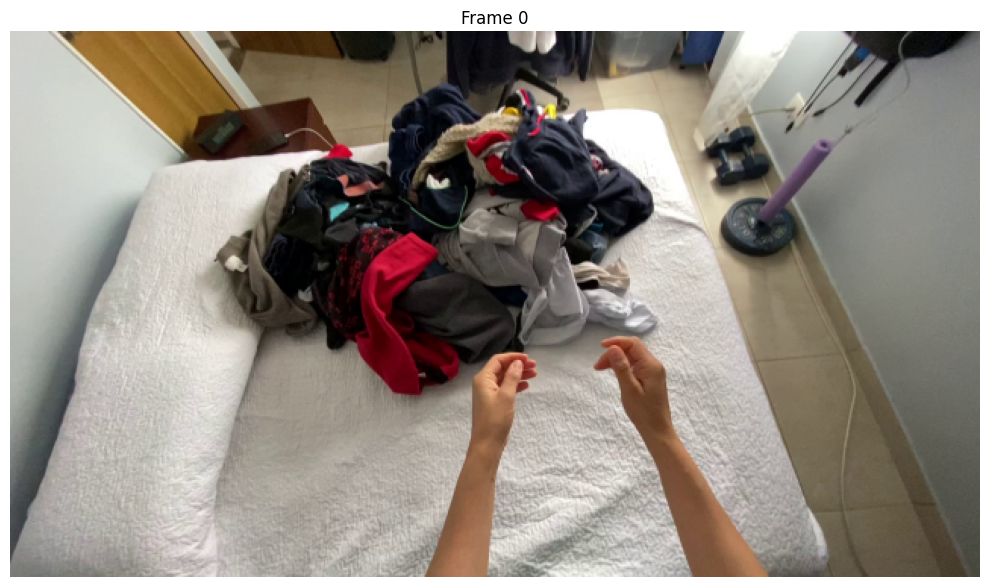

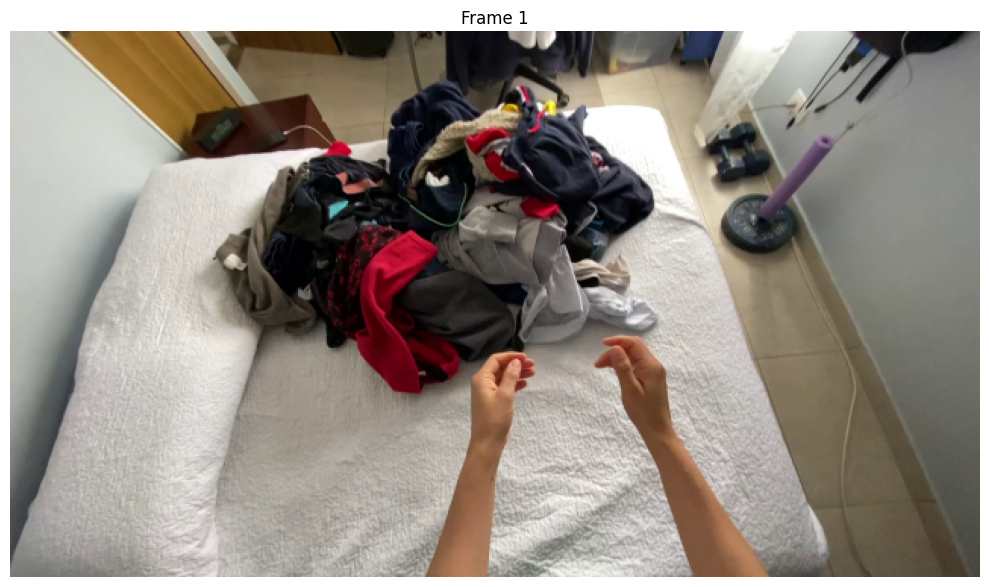

In [69]:

# Access specific frames by frame number
def get_frame(frame_num: int) -> np.ndarray:
    """Get a specific frame by frame number."""
    if len(images) == 0:
        raise IndexError("No frames available")
    if frame_num < 0 or frame_num >= len(images):
        raise IndexError(f"Frame {frame_num} out of range [0, {len(images)-1}]")
    return images[frame_num]


def display_frame(frame_num: int, figsize=(10, 8)):
    """Display a specific frame."""
    if len(images) == 0:
        print("❌ No frames available")
        return
    if frame_num < 0 or frame_num >= len(images):
        print(f"❌ Frame {frame_num} out of range [0, {len(images)-1}]")
        return

    img = get_frame(frame_num)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.title(f"Frame {frame_num}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


display_frame(0)  # Display the first frame
display_frame(1)  # Display the first frame

+--------+--------+
|      u |      v |
+========+========+
| 429.37 | 264.51 |
+--------+--------+
| 428.89 | 264.53 |
+--------+--------+
| 428.49 | 264.47 |
+--------+--------+
| 427.78 | 264.27 |
+--------+--------+
| 427.21 | 263.71 |
+--------+--------+
| 425.94 | 263.26 |
+--------+--------+
| 424.53 | 262.38 |
+--------+--------+
| 422.94 | 261.09 |
+--------+--------+
| 421.48 | 259.83 |
+--------+--------+
| 420.22 | 258.45 |
+--------+--------+
| 418.64 | 256.86 |
+--------+--------+
| 417.61 | 255.68 |
+--------+--------+
| 414.91 | 254.26 |
+--------+--------+
| 412.93 | 253.13 |
+--------+--------+
| 411.85 | 252.68 |
+--------+--------+
| 410.84 | 252.19 |
+--------+--------+
| 407.18 | 251.91 |
+--------+--------+
| 405.15 | 250.55 |
+--------+--------+
| 403.16 | 248.98 |
+--------+--------+
| 401.14 | 247.15 |
+--------+--------+
| 401.09 | 246.43 |
+--------+--------+
| 399.63 | 244.18 |
+--------+--------+
| 397.57 | 240.73 |
+--------+--------+
| 395.76 | 237.71 |


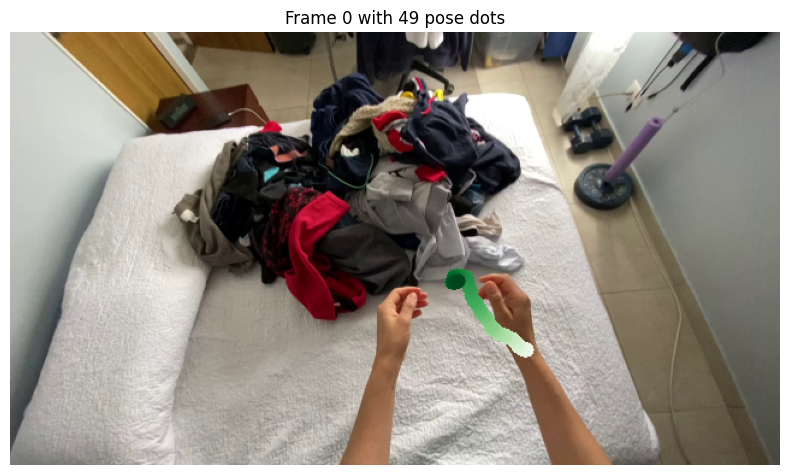

In [71]:
# Overlay all poses from final_poses starting at a chosen frame index
frame_idx = 0 # frame to display

try:

    # Collect points from frame_idx onward (camera-frame xyz)
    poses_arr = np.array(final_poses)
    if poses_arr.ndim != 2 or poses_arr.shape[1] < 3:
        raise ValueError(f"final_poses has unexpected shape {poses_arr.shape}")

    points_cam = poses_arr[frame_idx:, :3]
    if points_cam.size == 0:
        raise ValueError(f"No poses available from frame_idx {frame_idx} onward")

    # Project to pixel coordinates using the 640x360 intrinsics
    pixels = emu.cam_frame_to_cam_pixels(points_cam, emu.MECKA_INTRINSICS)
    pixels_2d = pixels[:, :2]

    print(tabulate(pixels_2d, headers=["u", "v"], tablefmt="grid", floatfmt=".2f"))


    frame = get_frame(frame_idx)
    frame_overlay = emu.draw_dot_on_frame(frame, pixels_2d, show=False, palette="Greens", dot_size=6)

    plt.figure(figsize=(8, 5))
    plt.imshow(frame_overlay)
    plt.title(f"Frame {frame_idx} with {len(points_cam)} pose dots")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Overlay failed: {e}")
